# Model hybride de HyConEx et HyperLogic sur Dry Bean

Ce notebook entraîne le nouveau module `nouveau_module` sur Dry Bean:
- binarisation bipolar {-1,+1} en entrée,
- hyperréseau **TabResNet** sur `x_bin` (forme `[B, D]`), puis **moyenne sur le batch** pour obtenir un contexte fixe et générer les poids du main network + tête CF (sans bruit ; LayerNorm pour gérer aussi `B=1`),
- couche règles type HyperLogic (porte h(u)=exp(-u^2/tau)),
- extraction de règles,
- évaluation des contrefactuels.

In [14]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from feature_engineering_dry_bean import prepare_dry_bean_splits
from nouveau_module import HybridDRConfig, HybridDRTrainer

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
np.set_printoptions(precision=4, suppress=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [15]:
splits = prepare_dry_bean_splits(
    test_size=0.2,
    val_size=0.2,
    random_state=42,
    add_engineered_features=True,
    clip_outliers=True,
)

print('Shapes:')
print('train:', splits.X_train.shape, splits.y_train.shape)
print('val  :', splits.X_val.shape, splits.y_val.shape)
print('test :', splits.X_test.shape, splits.y_test.shape)
print('n_features:', len(splits.feature_names))
print('n_classes :', len(splits.class_names))

pd.Series(splits.y_train).value_counts().sort_index().rename(index={i: c for i, c in enumerate(splits.class_names)})

Shapes:
train: (8710, 24) (8710,)
val  : (2178, 24) (2178,)
test : (2723, 24) (2723,)
n_features: 24
n_classes : 7


BARBUNYA     846
BOMBAY       334
CALI        1043
DERMASON    2269
HOROZ       1234
SEKER       1297
SIRA        1687
Name: count, dtype: int64

### Presets entraînement (TabResNet + porte HyperLogic)

Si la loss reste ~2.5 et l’AUROC ~0.5, la porte `exp(-u²/τ)` est souvent **trop étroite** (`τ` trop petit) ou la perte CF **tire trop** tôt.

Dans la cellule suivante, choisis **`PRESET`** :

| Preset | `temperature` (τ) | `cf_lambda` | `flip_lambda` | `lr` | Idée |
|--------|-------------------|-------------|---------------|------|------|
| **A** (défaut) | 0.8 | 0.15 | 0.06 | 1e-3 | Stabilité : porte plus douce, CF modéré |
| **B** | 0.8 | 0.28 | 0.08 | 1e-3 | Comme l’ancien notebook (CF plus fort) |
| **C** | 0.4 | 0.18 | 0.06 | 5e-4 | τ moyen + LR plus bas si A reste un peu plat |

Après avoir retrouvé une accuracy correcte, tu peux **baisser progressivement τ** et **remonter un peu `cf_lambda`**.


In [16]:
# --- Presets (voir cellule markdown au-dessus) ---
PRESET = "A"  # "A" | "B" | "C"

if PRESET == "A":
    _tau, _cf_l, _flip_l, _lr = 0.8, 0.15, 0.06, 1e-3
elif PRESET == "B":
    _tau, _cf_l, _flip_l, _lr = 0.8, 0.28, 0.08, 1e-3
elif PRESET == "C":
    _tau, _cf_l, _flip_l, _lr = 0.4, 0.18, 0.06, 5e-4
else:
    raise ValueError("PRESET doit être A, B ou C")

cfg = HybridDRConfig(
    seed=42,
    epochs=50,
    batch_size=128,
    lr=_lr,
    num_rules=64,
    bins_per_feature=4,
    hyper_hidden_dim=128,
    tabresnet_n_blocks=4,
    tabresnet_dropout=0.1,
    cf_lambda=_cf_l,
    flip_lambda=_flip_l,
    rule_sparsity_lambda=0.002,
    temperature=_tau,
)

trainer = HybridDRTrainer(cfg, device=device)
result = trainer.fit(
    splits.X_train,
    splits.y_train,
    x_val_cont=splits.X_val,
    y_val=splits.y_val,
    feature_names=splits.feature_names,
    class_names=splits.class_names,
    verbose=True,
)

test_metrics = trainer.evaluate(splits.X_test, splits.y_test, counterfactuals=True)

print('\nBest val accuracy:', f"{result.best_val_accuracy:.4f}")
print('Test accuracy    :', f"{test_metrics['accuracy']:.4f}")
print('Test AUROC OvR   :', test_metrics.get('auroc_ovr'))
print('CF validity      :', f"{test_metrics['counterfactuals']['validity_cf']:.4f}")
print('Changed bits mean:', f"{test_metrics['counterfactuals']['changed_bits_mean']:.4f}")
print('L1 cont mean     :', f"{test_metrics['counterfactuals']['proximity_l1_cont_mean']:.4f}")


[Epoch 001/50] loss=2.2344 val_acc=0.1414 best_val_acc=0.1414
[Epoch 002/50] loss=2.1960 val_acc=0.2608 best_val_acc=0.2608
[Epoch 003/50] loss=2.1893 val_acc=0.1938 best_val_acc=0.2608
[Epoch 004/50] loss=2.1748 val_acc=0.2608 best_val_acc=0.2608
[Epoch 005/50] loss=2.1869 val_acc=0.2608 best_val_acc=0.2608
[Epoch 006/50] loss=2.1852 val_acc=0.2608 best_val_acc=0.2608
[Epoch 007/50] loss=2.1733 val_acc=0.2736 best_val_acc=0.2736
[Epoch 008/50] loss=2.1544 val_acc=0.2658 best_val_acc=0.2736
[Epoch 009/50] loss=2.1529 val_acc=0.2828 best_val_acc=0.2828
[Epoch 010/50] loss=2.1570 val_acc=0.2824 best_val_acc=0.2828
[Epoch 011/50] loss=2.1336 val_acc=0.2851 best_val_acc=0.2851
[Epoch 012/50] loss=2.0746 val_acc=0.3480 best_val_acc=0.3480
[Epoch 013/50] loss=2.0208 val_acc=0.3687 best_val_acc=0.3687
[Epoch 014/50] loss=1.7905 val_acc=0.5693 best_val_acc=0.5693
[Epoch 015/50] loss=1.4259 val_acc=0.6400 best_val_acc=0.6400
[Epoch 016/50] loss=1.2892 val_acc=0.6635 best_val_acc=0.6635
[Epoch 0

In [17]:
history_df = pd.DataFrame(result.history)
(history_df.head(), history_df.tail())

(   epoch  train_loss  val_accuracy  best_val_accuracy
 0      1    2.234398      0.141414           0.141414
 1      2    2.196038      0.260790           0.260790
 2      3    2.189316      0.193756           0.260790
 3      4    2.174823      0.260790           0.260790
 4      5    2.186927      0.260790           0.260790,
     epoch  train_loss  val_accuracy  best_val_accuracy
 45     46    0.403221      0.884298           0.893939
 46     47    0.363386      0.885216           0.893939
 47     48    0.327095      0.888889           0.893939
 48     49    0.321734      0.894858           0.894858
 49     50    0.320357      0.889807           0.894858)

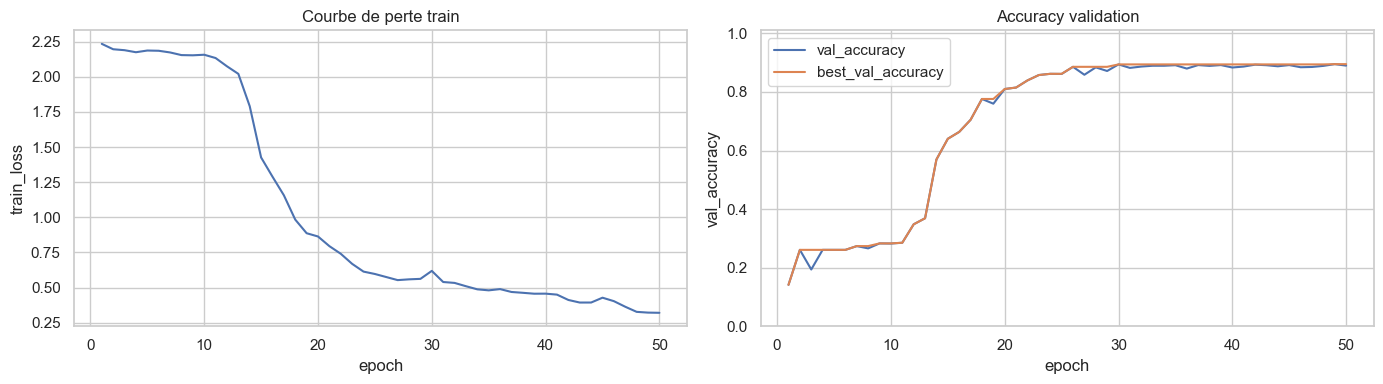

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=history_df, x='epoch', y='train_loss', ax=ax[0])
ax[0].set_title('Courbe de perte train')

sns.lineplot(data=history_df, x='epoch', y='val_accuracy', ax=ax[1], label='val_accuracy')
sns.lineplot(data=history_df, x='epoch', y='best_val_accuracy', ax=ax[1], label='best_val_accuracy')
ax[1].set_ylim(0.0, 1.01)
ax[1].set_title('Accuracy validation')
plt.tight_layout()
plt.show()

In [19]:
report_df = pd.DataFrame(test_metrics['classification_report']).transpose()
report_df

,precision,recall,f1-score,support
0,0.917355,0.837736,0.875740,265.000000
1,0.704762,0.711538,0.708134,104.000000
2,0.826347,0.846626,0.836364,326.000000
3,0.900576,0.881523,0.890948,709.000000
4,0.940722,0.945596,0.943152,386.000000
5,0.897619,0.928571,0.912833,406.000000
6,0.824074,0.844402,0.834114,527.000000
accuracy,0.875505,0.875505,0.875505,0.875505
macro avg,0.858779,0.856570,0.857326,2723.000000
weighted avg,0.876288,0.875505,0.875615,2723.000000


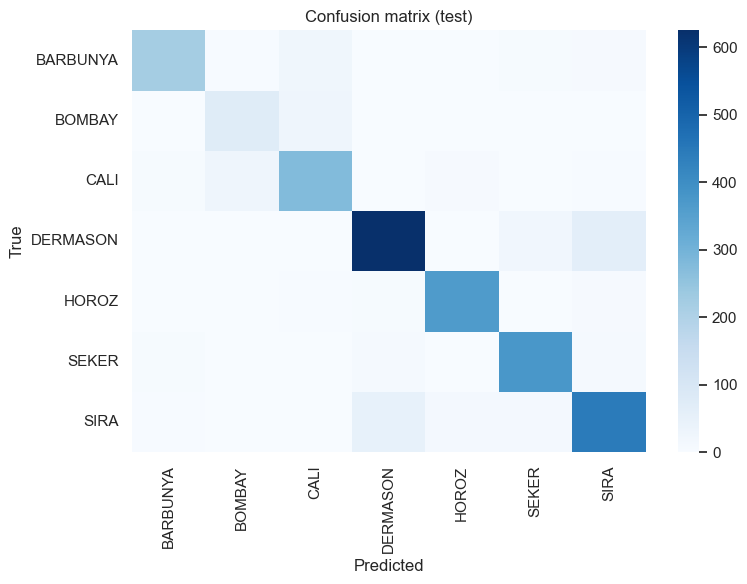

In [20]:
cm = np.array(test_metrics['confusion_matrix'])
cm_df = pd.DataFrame(cm, index=splits.class_names, columns=splits.class_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=False, cmap='Blues')
plt.title('Confusion matrix (test)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Règles extraites depuis le main network généré

In [21]:
from IPython.display import display

rules = trainer.export_rules(top_per_rule=4, min_abs_weight=0.05)
rules_df = pd.DataFrame(rules)
print('Nombre de règles extraites:', len(rules_df))

# Affichage complet : pas de troncature des colonnes (surtout la liste `if`).
rules_df_show = rules_df.copy()
rules_df_show['if'] = rules_df_show['if'].apply(lambda conds: ' AND\n'.join(conds))

with pd.option_context(
    'display.max_colwidth', None,
    'display.max_rows', None,
    'display.width', None,
):
    display(rules_df_show)

Nombre de règles extraites: 64


,rule_id,if,then_class,score
0,19,"roundness_bin1_[0.444,0.646)=-1 AND\nMajorAxisLength_bin3_[0.396,1.000)=-1 AND\nCompactness_bin2_[0.492,0.617)=+1 AND\nMinorAxisLength_bin3_[0.299,1.000)=-1",DERMASON,0.996216
1,50,"ShapeFactor1_bin1_[0.466,0.598)=-1 AND\nMajorAxisLength_bin2_[0.208,0.396)=-1 AND\nMinorAxisLength_bin2_[0.200,0.299)=-1 AND\nArea_over_Perimeter_bin1_[0.135,0.199)=-1",DERMASON,0.995257
2,22,"MinorAxisLength_bin0_[0.000,0.130)=-1 AND\nShapeFactor4_bin0_[0.000,0.728)=-1 AND\nShapeFactor1_bin3_[0.712,1.000)=-1 AND\nShapeFactor2_bin0_[0.000,0.178)=-1",SEKER,0.995009
3,38,"Extent_bin3_[0.822,1.000)=+1 AND\nCompactness_bin2_[0.492,0.617)=-1 AND\nShapeFactor2_bin2_[0.411,0.618)=-1 AND\nMinorAxisLength_bin3_[0.299,1.000)=-1",DERMASON,0.993125
4,46,"Area_over_Perimeter_bin0_[0.000,0.135)=-1 AND\nroundness_bin2_[0.646,0.779)=-1 AND\nlog_Perimeter_bin1_[0.187,0.303)=-1 AND\nPerimeter_bin1_[0.117,0.202)=-1",BARBUNYA,0.991938
5,62,"Roundness_x_Compactness_bin0_[0.000,0.325)=+1 AND\nMinorAxisLength_bin0_[0.000,0.130)=+1 AND\nMajorAxisLength_bin1_[0.103,0.208)=-1 AND\nRoundness_x_Compactness_bin1_[0.325,0.501)=-1",HOROZ,0.987841
6,41,"ShapeFactor4_bin0_[0.000,0.728)=-1 AND\nroundness_bin0_[0.000,0.444)=+1 AND\nroundness_bin1_[0.444,0.646)=-1 AND\nConvexArea_over_Area_bin2_[0.199,0.314)=-1",BARBUNYA,0.980631
7,61,"Eccentricity_bin2_[0.691,0.803)=+1 AND\nShapeFactor4_bin1_[0.728,0.857)=-1 AND\nCompactness_bin3_[0.617,1.000)=-1 AND\nAspectRation_bin1_[0.272,0.385)=-1",DERMASON,0.963530
8,40,"ShapeFactor1_bin0_[0.000,0.466)=-1 AND\nMajorAxisLength_bin2_[0.208,0.396)=-1 AND\nMajorAxisLength_bin3_[0.396,1.000)=+1 AND\nMajor_over_Minor_bin3_[0.530,1.000)=+1",HOROZ,0.952145
9,16,"MinorAxisLength_bin2_[0.200,0.299)=-1 AND\nConvexArea_bin1_[0.073,0.125)=+1 AND\nShapeFactor2_bin2_[0.411,0.618)=-1 AND\nlog_ConvexArea_bin1_[0.195,0.298)=-1",SIRA,0.951876


# Affichage d'une règle complète

In [ ]:
# Ici, "complète" = toutes les conditions dont |poids| >= min_abs_weight_full
# Mets min_abs_weight_full = 0.0 pour voir absolument tous les littéraux.
from nouveau_module.main_rule_net import unpack_main_params

assert trainer.model is not None

rule_id_to_show = int(rules_df.iloc[0]['rule_id'])  # change ici si tu veux une autre règle
min_abs_weight_full = 0.0

# Poids du main network via hyper TabResNet (sonde x_probe : batch [B,D] puis moyenne interne)
x_probe = torch.zeros((16, trainer.model.input_dim_bin), device=trainer.device, dtype=torch.float32)
with torch.no_grad():
    theta_main, _ = trainer.model.hyper(x_probe)

w_rule, _, w_out, _ = unpack_main_params(
    theta_main,
    input_dim=trainer.model.input_dim_bin,
    num_rules=trainer.model.num_rules,
    num_classes=trainer.model.num_classes,
)

wr = w_rule[:, rule_id_to_show].detach().cpu().numpy()
bin_names = trainer.binarizer.binary_feature_names()

active_idx = [i for i in range(len(wr)) if abs(wr[i]) >= min_abs_weight_full]
active_idx = sorted(active_idx, key=lambda i: abs(wr[i]), reverse=True)

full_conditions = [
    f"{bin_names[i]}={'+1' if wr[i] >= 0 else '-1'} (w={wr[i]:+.4f})"
    for i in active_idx
]

then_class_idx = int(w_out[rule_id_to_show].argmax().item())
then_class = trainer.class_names[then_class_idx]

print(f"rule_id = {rule_id_to_show}")
print(f"then_class = {then_class}")
print(f"nb_conditions_affichees = {len(full_conditions)}")
print("\nIF")
print(" AND\n".join(full_conditions))
print(f"\nTHEN class = {then_class}")

rule_id = 19
then_class = DERMASON
nb_conditions_affichees = 96

IF
roundness_bin1_[0.444,0.646)=-1 (w=-0.4651) AND
MajorAxisLength_bin3_[0.396,1.000)=-1 (w=-0.3900) AND
Compactness_bin2_[0.492,0.617)=+1 (w=+0.3554) AND
MinorAxisLength_bin3_[0.299,1.000)=-1 (w=-0.3417) AND
AspectRation_bin2_[0.385,0.530)=-1 (w=-0.3352) AND
ShapeFactor2_bin1_[0.178,0.411)=-1 (w=-0.3216) AND
Perimeter_bin2_[0.202,0.371)=-1 (w=-0.3185) AND
ConvexArea_over_Area_bin3_[0.314,1.000)=-1 (w=-0.3179) AND
log_ConvexArea_bin3_[0.456,1.000)=-1 (w=-0.3109) AND
ConvexArea_bin1_[0.073,0.125)=-1 (w=-0.2907) AND
Major_over_Minor_bin2_[0.385,0.530)=-1 (w=-0.2849) AND
ConvexArea_bin0_[0.000,0.073)=+1 (w=+0.2770) AND
ShapeFactor2_bin0_[0.000,0.178)=-1 (w=-0.2753) AND
Solidity_bin0_[0.000,0.681)=-1 (w=-0.2745) AND
log_Area_bin3_[0.455,1.000)=-1 (w=-0.2717) AND
Eccentricity_bin2_[0.691,0.803)=-1 (w=-0.2643) AND
EquivDiameter_bin2_[0.201,0.334)=-1 (w=-0.2600) AND
Compactness_bin0_[0.000,0.346)=-1 (w=-0.2586) AND
roundness_bin

# Analyse CF multi-cibles sur 10 samples correctement classés

In [23]:
# Pour chaque sample, on génère un contrefactuel vers TOUTES les classes cibles (sauf la classe source).
model = trainer.model
assert model is not None

x_test_bin = trainer.binarizer.transform(splits.X_test)
x_test_t = torch.tensor(x_test_bin, dtype=torch.float32, device=trainer.device)
with torch.no_grad():
    logits_test = model.predict_logits(x_test_t)
    y_pred_test = torch.argmax(logits_test, dim=1).cpu().numpy()

correct_pool = np.where(y_pred_test == splits.y_test)[0]
rng = np.random.default_rng(42)
n_examples = min(10, len(correct_pool))
idx = rng.choice(correct_pool, size=n_examples, replace=False)

x_sub = torch.tensor(x_test_bin[idx], dtype=torch.float32, device=trainer.device)
y_sub = torch.tensor(splits.y_test[idx], dtype=torch.long, device=trainer.device)
y_pred_orig = torch.tensor(y_pred_test[idx], dtype=torch.long, device=trainer.device)

num_classes = len(splits.class_names)
with torch.no_grad():
    x_cf_all, logits_cf_all = model.generate_counterfactuals_all_classes(x_sub, y_pred_orig)
    y_pred_cf_all = torch.argmax(logits_cf_all, dim=2)  # [B, C]

x_sub_np = x_sub.cpu().numpy()
x_cf_all_np = x_cf_all.cpu().numpy()  # [B, C, D]
y_true_np = y_sub.cpu().numpy()
y_pred_orig_np = y_pred_orig.cpu().numpy()
y_pred_cf_all_np = y_pred_cf_all.cpu().numpy()

bin_names = trainer.binarizer.binary_feature_names()
rows = []
for i in range(n_examples):
    for target_cls in range(num_classes):
        # On saute la classe source, car ce n'est pas une cible CF.
        if target_cls == int(y_pred_orig_np[i]):
            continue

        delta_bits = np.abs(x_cf_all_np[i, target_cls] - x_sub_np[i])
        changed_idx = np.where(delta_bits > 1e-6)[0]
        top_idx = changed_idx[:8]

        rows.append(
            {
                'sample_index_test': int(idx[i]),
                'y_true': splits.class_names[int(y_true_np[i])],
                'y_pred_orig': splits.class_names[int(y_pred_orig_np[i])],
                'target_cf': splits.class_names[int(target_cls)],
                'y_pred_cf': splits.class_names[int(y_pred_cf_all_np[i, target_cls])],
                'valid_cf': bool(y_pred_cf_all_np[i, target_cls] == target_cls),
                'changed_bits_count': int(len(changed_idx)),
                'changed_bits_top': [bin_names[j] for j in top_idx],
            }
        )

cf_df = pd.DataFrame(rows)

print('Nb lignes = n_samples * (n_classes - 1) :', len(cf_df))
print('Taux global de validité CF :', f"{cf_df['valid_cf'].mean():.4f}")

# Vue détaillée par (sample, cible)
cf_df

Nb lignes = n_samples * (n_classes - 1) : 60
Taux global de validité CF : 1.0000


,sample_index_test,y_true,y_pred_orig,target_cf,y_pred_cf,valid_cf,changed_bits_count,changed_bits_top
0,228,SEKER,SEKER,BARBUNYA,BARBUNYA,True,53,"[Area_bin3_[0.229,1.000), Perimeter_bin0_[0.00..."
1,228,SEKER,SEKER,BOMBAY,BOMBAY,True,54,"[Area_bin3_[0.229,1.000), Perimeter_bin0_[0.00..."
2,228,SEKER,SEKER,CALI,CALI,True,53,"[Area_bin3_[0.229,1.000), Perimeter_bin0_[0.00..."
3,228,SEKER,SEKER,DERMASON,DERMASON,True,52,"[Area_bin3_[0.229,1.000), Perimeter_bin0_[0.00..."
4,228,SEKER,SEKER,HOROZ,HOROZ,True,52,"[Area_bin3_[0.229,1.000), Perimeter_bin0_[0.00..."
5,228,SEKER,SEKER,SIRA,SIRA,True,51,"[Area_bin3_[0.229,1.000), Perimeter_bin0_[0.00..."
6,2109,SEKER,SEKER,BARBUNYA,BARBUNYA,True,51,"[Area_bin0_[0.000,0.074), Area_bin1_[0.074,0.1..."
7,2109,SEKER,SEKER,BOMBAY,BOMBAY,True,53,"[Area_bin0_[0.000,0.074), Area_bin1_[0.074,0.1..."
8,2109,SEKER,SEKER,CALI,CALI,True,54,"[Area_bin0_[0.000,0.074), Area_bin1_[0.074,0.1..."
9,2109,SEKER,SEKER,DERMASON,DERMASON,True,51,"[Area_bin0_[0.000,0.074), Area_bin1_[0.074,0.1..."


# Contrefactuels complets pour UNE prediction vers TOUTES les classes cibles

In [24]:

sample_pos = 0  # position dans les 10 samples tirés (cellule précédente)

model = trainer.model
assert model is not None

# Récupération de l'index test du sample choisi dans la cellule précédente
sample_index_test = int(idx[sample_pos])
y_true_idx = int(splits.y_test[sample_index_test])

y_source_name = splits.class_names[y_true_idx]

# Encodage binaire du sample
x_bin_full = trainer.binarizer.transform(splits.X_test)
x_src_bin = torch.tensor(x_bin_full[sample_index_test:sample_index_test+1], dtype=torch.float32, device=trainer.device)

# Dans ce notebook, la classe source est correctement prédite (pool filtré en amont)
y_source = torch.tensor([y_true_idx], dtype=torch.long, device=trainer.device)

with torch.no_grad():
    x_cf_all, logits_cf_all = model.generate_counterfactuals_all_classes(x_src_bin, y_source)

x_src_bin_np = x_src_bin[0].cpu().numpy()
x_src_cont = trainer.binarizer.binary_to_continuous(x_src_bin_np.reshape(1, -1))[0]
bin_names = trainer.binarizer.binary_feature_names()

print('Sample index test :', sample_index_test)
print('y_true / source   :', y_source_name)

for target_idx, target_name in enumerate(splits.class_names):
    if target_idx == y_true_idx:
        continue

    x_cf_bin = x_cf_all[0, target_idx].cpu().numpy()
    y_pred_cf_idx = int(torch.argmax(logits_cf_all[0, target_idx]).item())

    changed_idx = np.where(np.abs(x_cf_bin - x_src_bin_np) > 1e-6)[0]

    # Projection continue pour lecture humaine
    x_cf_cont = trainer.binarizer.binary_to_continuous(x_cf_bin.reshape(1, -1))[0]

    rows_bits = []
    for j in changed_idx:
        rows_bits.append(
            {
                'binary_feature': bin_names[j],
                'src_bit': int(x_src_bin_np[j]),
                'cf_bit': int(x_cf_bin[j]),
            }
        )
    changes_bits_df = pd.DataFrame(rows_bits)
    if not changes_bits_df.empty:
        # Garde uniquement les vrais flips de bits.
        changes_bits_df = changes_bits_df.loc[changes_bits_df['src_bit'] != changes_bits_df['cf_bit']].reset_index(drop=True)

    cont_changes_df = pd.DataFrame(
        {
            'feature': splits.feature_names,
            'x_src_cont': x_src_cont,
            'x_cf_cont': x_cf_cont,
            'delta': x_cf_cont - x_src_cont,
        }
    )
    cont_changes_df = cont_changes_df.loc[cont_changes_df['delta'].abs() > 1e-9].sort_values('delta', key=np.abs, ascending=False)

    print('\n' + '=' * 90)
    print('target_cf         :', target_name)
    print('y_pred_cf         :', splits.class_names[y_pred_cf_idx])
    print('valid_cf          :', y_pred_cf_idx == target_idx)
    print('changed_bits_count:', len(changed_idx))

    print('\nBits modifiés (complet):')
    display(changes_bits_df)

    print('\nProjection continue (features effectivement changées):')
    display(cont_changes_df)

Sample index test : 228
y_true / source   : SEKER

target_cf         : BARBUNYA
y_pred_cf         : BARBUNYA
valid_cf          : True
changed_bits_count: 53

Bits modifiés (complet):


,binary_feature,src_bit,cf_bit
0,"Area_bin3_[0.229,1.000)",-1,1
1,"Perimeter_bin0_[0.000,0.117)",1,-1
2,"Perimeter_bin1_[0.117,0.202)",-1,1
3,"MajorAxisLength_bin0_[0.000,0.103)",1,-1
4,"MajorAxisLength_bin3_[0.396,1.000)",-1,1
5,"MinorAxisLength_bin1_[0.130,0.200)",-1,1
6,"MinorAxisLength_bin2_[0.200,0.299)",1,-1
7,"AspectRation_bin1_[0.272,0.385)",-1,1
8,"AspectRation_bin2_[0.385,0.530)",-1,1
9,"AspectRation_bin3_[0.530,1.000)",-1,1



Projection continue (features effectivement changées):


,feature,x_src_cont,x_cf_cont,delta
13,ShapeFactor2,0.809108,0.089249,-0.719859
19,Roundness_x_Compactness,0.820125,0.162455,-0.657670
2,MajorAxisLength,0.051290,0.698193,0.646903
20,SF_sum,0.789984,0.151089,-0.638895
15,ShapeFactor4,0.964237,0.364231,-0.600007
8,Extent,0.761957,0.258630,-0.503328
9,Solidity,0.833840,0.340433,-0.493408
5,Eccentricity,0.285731,0.746945,0.461215
14,ShapeFactor3,0.788926,0.379746,-0.409180
11,Compactness,0.808397,0.418983,-0.389413



target_cf         : BOMBAY
y_pred_cf         : BOMBAY
valid_cf          : True
changed_bits_count: 54

Bits modifiés (complet):


...

,feature,x_src_cont,x_cf_cont,delta
13,ShapeFactor2,0.809108,0.089249,-0.719859
19,Roundness_x_Compactness,0.820125,0.162455,-0.657670
2,MajorAxisLength,0.051290,0.698193,0.646903
20,SF_sum,0.789984,0.151089,-0.638895
15,ShapeFactor4,0.964237,0.364231,-0.600007
8,Extent,0.761957,0.258630,-0.503328
9,Solidity,0.833840,0.340433,-0.493408
5,Eccentricity,0.285731,0.746945,0.461215
14,ShapeFactor3,0.788926,0.379746,-0.409180
11,Compactness,0.808397,0.418983,-0.389413



target_cf         : SIRA
y_pred_cf         : SIRA
valid_cf          : True
changed_bits_count: 51

Bits modifiés (complet):


,binary_feature,src_bit,cf_bit
0,"Area_bin3_[0.229,1.000)",-1,1
1,"Perimeter_bin0_[0.000,0.117)",1,-1
2,"Perimeter_bin1_[0.117,0.202)",-1,1
3,"MajorAxisLength_bin0_[0.000,0.103)",1,-1
4,"MajorAxisLength_bin3_[0.396,1.000)",-1,1
5,"MinorAxisLength_bin1_[0.130,0.200)",-1,1
6,"MinorAxisLength_bin2_[0.200,0.299)",1,-1
7,"AspectRation_bin1_[0.272,0.385)",-1,1
8,"AspectRation_bin2_[0.385,0.530)",-1,1
9,"AspectRation_bin3_[0.530,1.000)",-1,1



Projection continue (features effectivement changées):


,feature,x_src_cont,x_cf_cont,delta
13,ShapeFactor2,0.809108,0.089249,-0.719859
19,Roundness_x_Compactness,0.820125,0.162455,-0.657670
2,MajorAxisLength,0.051290,0.698193,0.646903
20,SF_sum,0.789984,0.151089,-0.638895
15,ShapeFactor4,0.964237,0.364231,-0.600007
9,Solidity,0.833840,0.340433,-0.493408
5,Eccentricity,0.285731,0.746945,0.461215
11,Compactness,0.808397,0.418983,-0.389413
10,roundness,0.889402,0.544771,-0.344631
12,ShapeFactor1,0.532132,0.232940,-0.299192


## Lecture rapide

- `accuracy` / `AUROC`: qualité de classification.
- `CF validity`: proportion de CF atteignant la classe cible.
- Dans la table `cf_df`, chaque ligne correspond à un couple `(sample, target_cf)`.
- `changed_bits_count`: nombre de bits modifiés pour atteindre la cible.
- `rules_df`: règles IF-THEN extraites du main network.